In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from data import BreathDataset, load_dataset, split_dataset
from models.vae import VAE

plt.rcParams.update({'legend.fontsize': 9,
                     'axes.titlesize': 10})

In [2]:
def plot_reconstruction(model, train_ds, region, device):
    model.eval()

    # denormalization
    mean = train_ds.stats['mean'][:, None]
    std  = train_ds.stats['std'][:, None]
    def denorm(x):
        return x * std + mean

    # plot
    fig, axes = plt.subplots(2, 3, figsize=(14, 4), sharex=True, sharey='row')
    fig.suptitle(f'VAE Reconstruction: {region}')
    channel_names = ['Humidity in %', 'Temperature in °C']

    sample_indices = np.random.default_rng(42).choice(len(train_ds), size=3, replace=False)
    for col, idx in enumerate(sample_indices):
        signal, time, label = train_ds[idx]
        signal_batch = signal.unsqueeze(0).to(device)
        with torch.no_grad():
            x_hat, _, _ = model(signal_batch)
        x_hat      = denorm(x_hat.squeeze(0).cpu().numpy())
        signal_np  = denorm(signal.numpy())
        time_np    = time.numpy()

        for row in range(2):
            ax = axes[row, col]
            ax.plot(time_np, signal_np[row], label='real', color='tab:blue')
            ax.plot(time_np, x_hat[row], label='reconstruction', color='tab:orange', linestyle='--')
            ax.grid()
            axes[row, 0].set_ylabel(channel_names[row])
            axes[0, col].set_title(f'Sample {idx}')
            axes[0, 0].legend(loc='upper left')
            axes[-1, col].set_xlabel('Time in s')
    plt.tight_layout()
    plt.show()

def plot_generation(model, train_ds, region, device):
    model.eval()
    # denormalization
    mean = train_ds.stats['mean'][:, None]
    std  = train_ds.stats['std'][:, None]
    def denorm(x):
        return x * std + mean
    
    # plot
    samples  = denorm(model.sample(9, device).cpu().numpy())
    time_np  = train_ds[0][1].numpy()

    fig, axes = plt.subplots(3, 3, figsize=(14, 6), sharex=True, sharey=False)
    fig.suptitle(f'VAE Generated Samples: {region}')
    for i, ax in enumerate(axes.flatten()):
        row = i // 3
        col = i % 3
        l1, = ax.plot(time_np, samples[i, 0], color='tab:blue', label='Humidity in %')
        ax.grid()
        ax_r = ax.twinx()
        l2, = ax_r.plot(time_np, samples[i, 1], color='tab:orange', label='Temperature in °C')
        if col == 0:
            ax.set_ylabel('Humidity in %', color='tab:blue')
            ax.tick_params(axis='y', colors='tab:blue')
        else:
            ax.set_yticklabels([])
            ax.tick_params(axis='y', length=0)
        if col == 2:
            ax_r.set_ylabel('Temperature in °C', color='tab:orange')
            ax_r.tick_params(axis='y', colors='tab:orange')
        else:
            ax_r.set_yticklabels([])
            ax_r.tick_params(axis='y', length=0)
        if row == 2:
            ax.set_xlabel('Time in s')
    plt.tight_layout()
    plt.show()

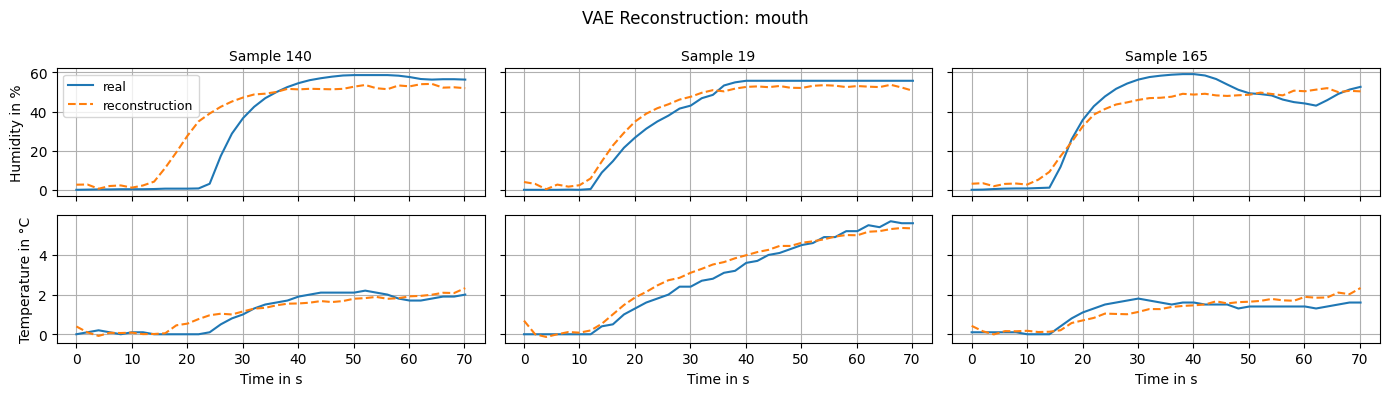

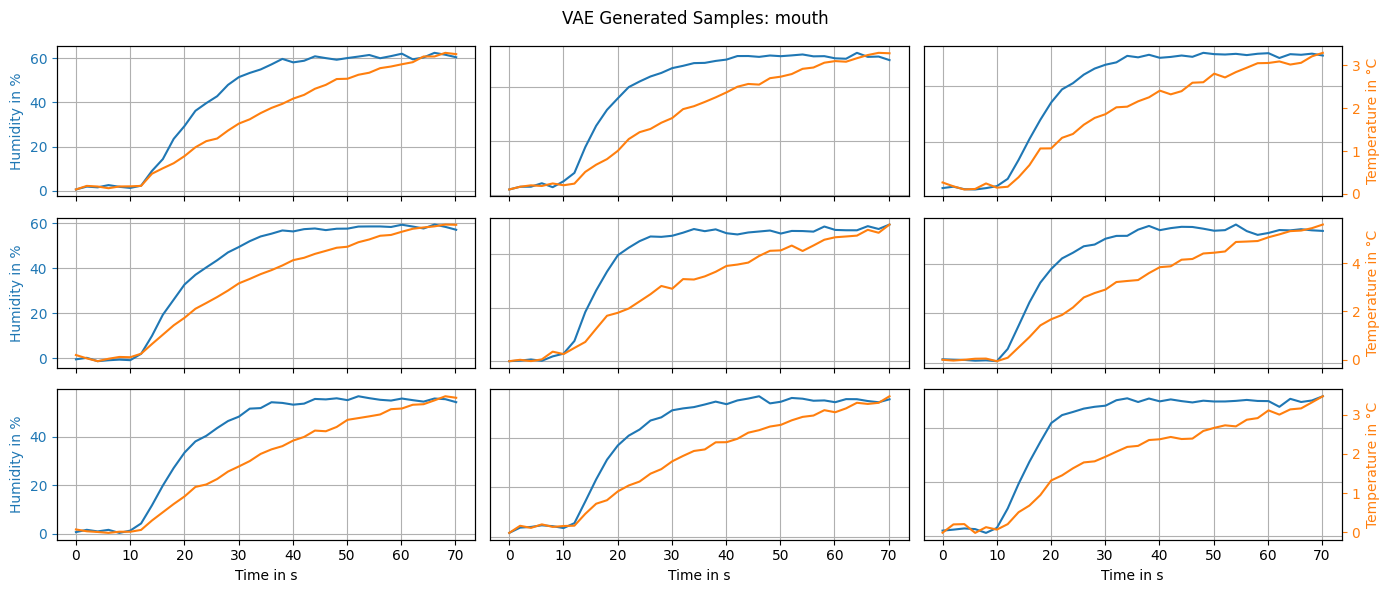

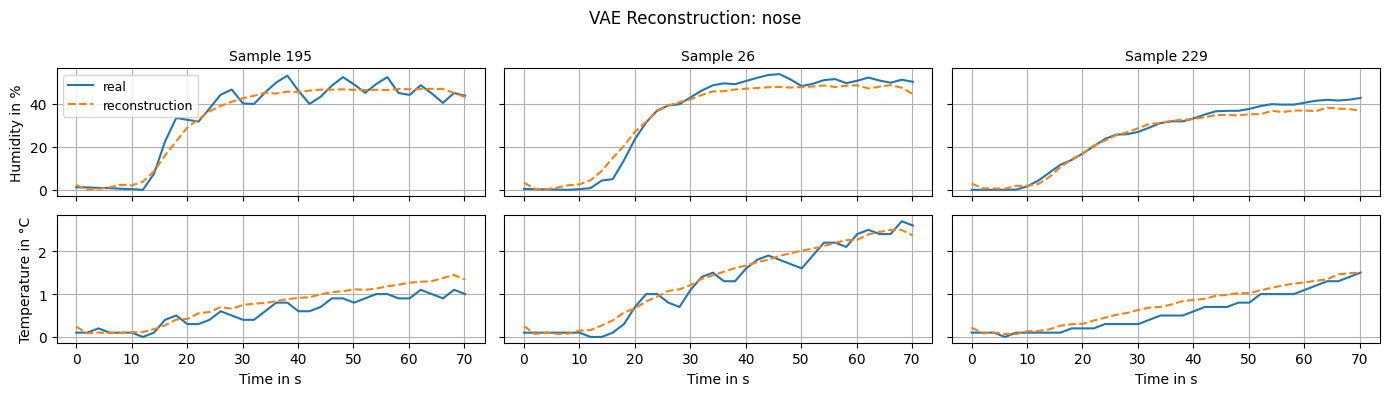

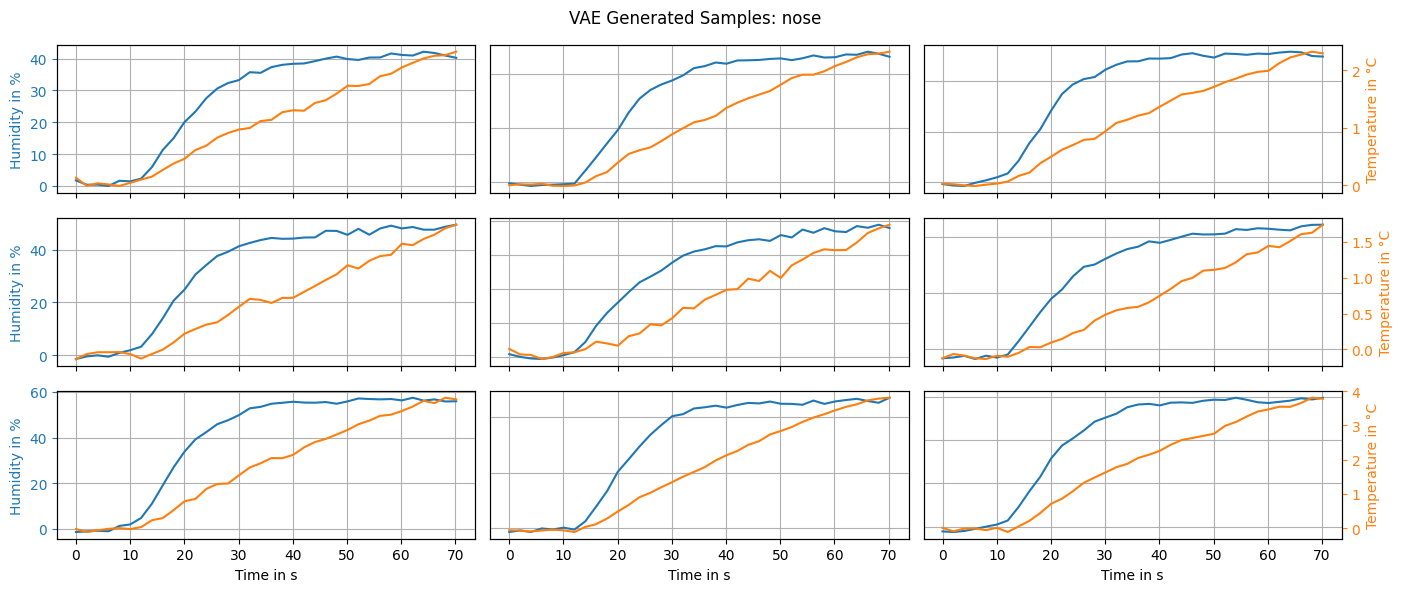

In [3]:
# params
regions = ['mouth', 'nose']
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')

for region in regions:
    # load dataset
    df = load_dataset()
    df = df[df['region'] == region].reset_index(drop=True)
    df_train, df_val, df_test = split_dataset(df, random_state=42)
    train_ds = BreathDataset(df_train)

    # load best model
    ckpt_path = f'checkpoints/vae_{region}.pt'
    model = VAE(latent_dim=16).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])

    plot_reconstruction(model, train_ds, region, device)
    plot_generation(model, train_ds, region, device)